### Analyse AND Modelisation

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier

### Chargement des données **Events et Mentions**

In [2]:
events = pd.read_csv('../data/gdelt_benin_2025_clean.csv')

mentions = pd.read_csv("../data/gdelt_benin_2025_mentions.csv")

### EDA FAST

In [3]:
events.describe()

,GlobalEventID,MonthYear,Year,FractionDate,IsRootEvent,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,...,Actor1Geo_Long,Actor2Geo_Type,Actor2Geo_Lat,Actor2Geo_Long,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,DATEADDED,mois,semaine
count,1.904200e+04,19042.000000,19042.0,19042.000000,19042.000000,19042.000000,19042.000000,19042.000000,19042.000000,19042.000000,...,17544.000000,19042.000000,14014.000000,14014.000000,19042.000000,19042.000000,19042.000000,1.904200e+04,19042.000000,19042.000000
mean,1.252831e+09,202506.960403,2025.0,2025.529332,0.618738,96.577618,69.552673,6.788520,1.791251,0.408655,...,2.932901,1.136540,10.672975,2.803888,1.271243,9.414711,2.257319,2.025071e+13,6.960403,28.286525
std,1.933336e+07,3.702120,0.0,0.302850,0.485710,186.027772,55.642545,5.560848,1.141509,4.593209,...,11.792007,1.240245,7.280047,11.187603,0.884069,0.660111,0.168041,3.694823e+08,3.702120,16.063714
min,1.218370e+09,202501.000000,2025.0,2025.002700,0.000000,10.000000,10.000000,1.000000,1.000000,-10.000000,...,-122.271000,0.000000,-42.000000,-122.271000,1.000000,6.280360,0.869667,2.025010e+13,1.000000,1.000000
25%,1.236708e+09,202504.000000,2025.0,2025.268500,0.000000,36.000000,31.000000,3.000000,1.000000,-2.000000,...,2.250000,0.000000,9.500000,2.250000,1.000000,9.500000,2.250000,2.025041e+13,4.000000,14.000000
50%,1.252805e+09,202507.000000,2025.0,2025.542500,1.000000,50.000000,46.000000,4.000000,1.000000,1.900000,...,2.250000,1.000000,9.500000,2.250000,1.000000,9.500000,2.250000,2.025072e+13,7.000000,29.000000
75%,1.271907e+09,202511.000000,2025.0,2025.824700,1.000000,111.000000,110.000000,11.000000,3.000000,3.400000,...,2.250000,1.000000,9.500000,2.250000,1.000000,9.500000,2.250000,2.025110e+13,11.000000,44.000000
max,1.281700e+09,202512.000000,2025.0,2025.989000,1.000000,1823.000000,195.000000,19.000000,4.000000,10.000000,...,145.096000,5.000000,64.000000,174.000000,5.000000,12.407400,3.389890,2.025123e+13,12.000000,52.000000


In [4]:
mentions.describe()

,GlobalEventID,EventTimeDate,MentionTimeDate,MentionType,SentenceID,Actor1CharOffset,Actor2CharOffset,ActionCharOffset,InRawText,Confidence,MentionDocLen,MentionDocTone
count,2.543900e+04,2.543900e+04,2.543900e+04,25439.0,25439.000000,25439.000000,25439.000000,25439.000000,25439.000000,25439.000000,25439.000000,25439.000000
mean,1.254418e+09,2.025074e+13,2.025074e+13,1.0,7.512795,1751.875192,1379.890365,1909.431149,0.546209,48.440976,4125.980424,-1.820882
std,1.995843e+07,3.823884e+08,3.823910e+08,0.0,7.997183,2480.659832,2357.571453,2490.582899,0.497870,31.790385,4697.348617,4.523516
min,1.218370e+09,2.025010e+13,2.025010e+13,1.0,1.000000,-1.000000,-1.000000,-1.000000,0.000000,10.000000,114.000000,-17.241379
25%,1.237728e+09,2.025041e+13,2.025041e+13,1.0,3.000000,294.000000,-1.000000,450.000000,0.000000,20.000000,2037.000000,-4.954268
50%,1.254130e+09,2.025073e+13,2.025073e+13,1.0,5.000000,1054.000000,527.000000,1232.000000,1.000000,40.000000,2972.000000,-1.929260
75%,1.274860e+09,2.025112e+13,2.025112e+13,1.0,10.000000,2293.500000,1889.500000,2445.500000,1.000000,80.000000,4737.000000,1.236476
max,1.281700e+09,2.025123e+13,2.025123e+13,1.0,126.000000,39149.000000,39242.000000,39155.000000,1.000000,100.000000,61818.000000,15.789474


In [5]:
mentions.columns.tolist()

['GlobalEventID',
 'EventTimeDate',
 'MentionTimeDate',
 'MentionType',
 'MentionSourceName',
 'MentionIdentifier',
 'SentenceID',
 'Actor1CharOffset',
 'Actor2CharOffset',
 'ActionCharOffset',
 'InRawText',
 'Confidence',
 'MentionDocLen',
 'MentionDocTone']

In [6]:
events.columns.to_list()

['GlobalEventID',
 'SQLDATE',
 'MonthYear',
 'Year',
 'FractionDate',
 'Actor1Code',
 'Actor1Name',
 'Actor1CountryCode',
 'Actor1Type1Code',
 'Actor2Code',
 'Actor2Name',
 'Actor2CountryCode',
 'Actor2Type1Code',
 'IsRootEvent',
 'EventCode',
 'EventBaseCode',
 'EventRootCode',
 'QuadClass',
 'GoldsteinScale',
 'NumMentions',
 'NumSources',
 'NumArticles',
 'AvgTone',
 'Actor1Geo_Type',
 'Actor1Geo_FullName',
 'Actor1Geo_CountryCode',
 'Actor1Geo_ADM1Code',
 'Actor1Geo_ADM2Code',
 'Actor1Geo_Lat',
 'Actor1Geo_Long',
 'Actor1Geo_FeatureID',
 'Actor2Geo_Type',
 'Actor2Geo_FullName',
 'Actor2Geo_CountryCode',
 'Actor2Geo_ADM1Code',
 'Actor2Geo_ADM2Code',
 'Actor2Geo_Lat',
 'Actor2Geo_Long',
 'Actor2Geo_FeatureID',
 'ActionGeo_Type',
 'ActionGeo_FullName',
 'ActionGeo_CountryCode',
 'ActionGeo_ADM1Code',
 'ActionGeo_Lat',
 'ActionGeo_Long',
 'ActionGeo_FeatureID',
 'DATEADDED',
 'SOURCEURL',
 'mois',
 'mois_nom',
 'semaine']

Ici nous allons passer à modelisation des données en testant 03 Algorithmes de Clustering afin
de s'aligner sur l'un de nos objectifs de :

**Analyser l'image du pays Bénin à l'echelle international** : elle nous permettra de savoir comment les médias mondiaux percoivent le Bénin et de savoir si la couverture médiatique internationale est globalement critique ou traite de sujets durs (conflits, criminalité, crises).

**### DBSCAN**

**### Gaussian Mixture**

**### Spectral Clustering**

In [7]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import DBSCAN, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

In [8]:
events["Actor1Geo_Type"]

0        1
1        1
2        1
3        1
4        1
        ..
19037    1
19038    1
19039    1
19040    1
19041    1
Name: Actor1Geo_Type, Length: 19042, dtype: int64

In [9]:
events_features = ["GlobalEventID", "AvgTone", "GoldsteinScale", "NumMentions", "NumSources",
"Actor1Name", "Actor2Name", "Actor1CountryCode", "Actor1Type1Code", "Actor2Type1Code", "EventRootCode",
"Actor1Geo_CountryCode", "Actor1Geo_FullName","SQLDATE", "Actor1Geo_Type", "ActionGeo_Lat", "ActionGeo_Long"]

df_events = events[events_features]
df_events.head()

,GlobalEventID,AvgTone,GoldsteinScale,NumMentions,NumSources,Actor1Name,Actor2Name,Actor1CountryCode,Actor1Type1Code,Actor2Type1Code,EventRootCode,Actor1Geo_CountryCode,Actor1Geo_FullName,SQLDATE,Actor1Geo_Type,ActionGeo_Lat,ActionGeo_Long
0,1218370051,-12.206573,3.0,10,1,BENIN,NaN,BEN,NaN,NaN,2,BN,Benin,2025-01-01,1,9.5,2.25
1,1218370053,-5.581395,1.9,2,1,BENIN,NIGERIEN,BEN,NaN,NaN,4,BN,Benin,2025-01-01,1,9.5,2.25
2,1218370054,-5.581395,-2.0,2,1,BENINESE,NIGERIEN,BEN,NaN,NaN,11,BN,Benin,2025-01-01,1,9.5,2.25
3,1218370056,-5.581395,-6.5,10,1,BENIN,NIGER,BEN,NaN,GOV,14,BN,Benin,2025-01-01,1,9.5,2.25
4,1218370058,-5.581395,1.9,8,1,BENINESE,NIGERIEN,BEN,GOV,NaN,4,BN,Benin,2025-01-01,1,9.5,2.25


In [10]:
mentions_summary = mentions.groupby('GlobalEventID').agg({
    'Confidence': 'mean',
    'MentionDocTone': 'mean',
    'MentionDocLen': 'mean'
}).reset_index()

In [11]:
print("Colonnes Events:", events.columns.tolist())
print("Colonnes Mentions:", mentions.columns.tolist())

Colonnes Events: ['GlobalEventID', 'SQLDATE', 'MonthYear', 'Year', 'FractionDate', 'Actor1Code', 'Actor1Name', 'Actor1CountryCode', 'Actor1Type1Code', 'Actor2Code', 'Actor2Name', 'Actor2CountryCode', 'Actor2Type1Code', 'IsRootEvent', 'EventCode', 'EventBaseCode', 'EventRootCode', 'QuadClass', 'GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles', 'AvgTone', 'Actor1Geo_Type', 'Actor1Geo_FullName', 'Actor1Geo_CountryCode', 'Actor1Geo_ADM1Code', 'Actor1Geo_ADM2Code', 'Actor1Geo_Lat', 'Actor1Geo_Long', 'Actor1Geo_FeatureID', 'Actor2Geo_Type', 'Actor2Geo_FullName', 'Actor2Geo_CountryCode', 'Actor2Geo_ADM1Code', 'Actor2Geo_ADM2Code', 'Actor2Geo_Lat', 'Actor2Geo_Long', 'Actor2Geo_FeatureID', 'ActionGeo_Type', 'ActionGeo_FullName', 'ActionGeo_CountryCode', 'ActionGeo_ADM1Code', 'ActionGeo_Lat', 'ActionGeo_Long', 'ActionGeo_FeatureID', 'DATEADDED', 'SOURCEURL', 'mois', 'mois_nom', 'semaine']
Colonnes Mentions: ['GlobalEventID', 'EventTimeDate', 'MentionTimeDate', 'MentionType', 'MentionS

In [12]:
# Supposons que nous utilisions les colonnes d'impact et de tonalité directement du fichier events si la jointure échoue
features_scale = ['GoldsteinScale', 'AvgTone', 'NumMentions', 'NumArticles', 'NumSources']
X_feature = events[features_scale].dropna()

In [13]:
# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feature)

print(X_scaled.ndim)

2


In [14]:
print(X_scaled)

[[ 0.56418366 -2.24724068  1.41154197  1.51168317 -0.08446249]
 [ 0.32469339 -0.83485345 -0.84308892 -0.86475273 -0.08446249]
 [-0.52440849 -0.83485345 -0.84308892 -0.86475273 -0.08446249]
 ...
 [-2.26615593 -1.72737608  0.84788425  0.9175742  -0.08446249]
 [-2.26615593 -1.72737608 -0.84308892 -0.86475273 -0.08446249]
 [-2.26615593 -1.72737608  0.84788425  0.9175742  -0.08446249]]


### Modelisation

#### 1- DBSCAN Algorithms

In [15]:
# 1. DBSCAN (Identifier les événements atypiques/risques)
dbscan = DBSCAN(eps=0.5, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled)


n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
print(f'Clusters trouves : {n_clusters}')

Clusters trouves : 2


In [16]:
outliers = X_scaled[db_labels == -1]
clusters = X_feature[db_labels != -1]
print(f'Outliers : {len(outliers)} points suspects')

Outliers : 445 points suspects


#### Gaussian Mixture

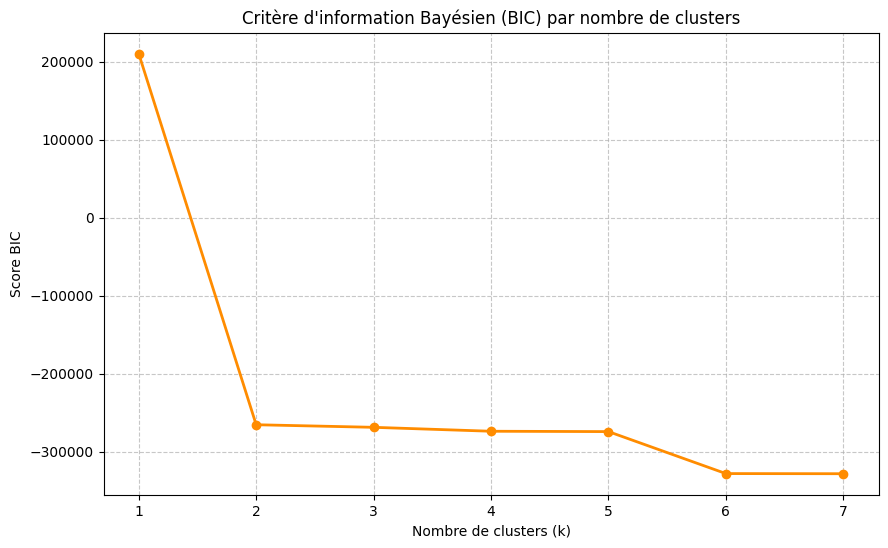

Scores BIC obtenus : [210007.87149590102, -265497.31854068337, -268808.51971788955, -273841.458967017, -274298.17382823554, -328095.40076110436, -328279.4149228265]


In [17]:
import matplotlib.pyplot as plt
scores = []

for i in range(1, 8):

    gmm = GaussianMixture(n_components=i, random_state=42)
    gmm_labels = gmm.fit_predict(X_scaled)

    scores.append(gmm.bic(X_scaled))
# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(range(1,8), scores, marker='o', color='darkorange', linewidth=2)
plt.title('Critère d\'information Bayésien (BIC) par nombre de clusters')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score BIC')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
print("Scores BIC obtenus :", scores)

#### Optimisation de GMM (N_components=5)

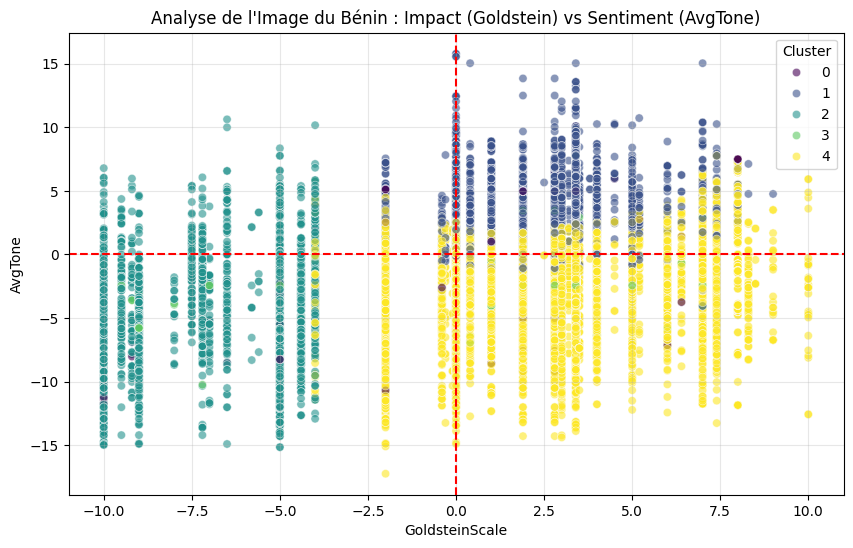

/tmp/ipykernel_24232/2831076472.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_full, x='Cluster', y='NumMentions', palette='Set2')


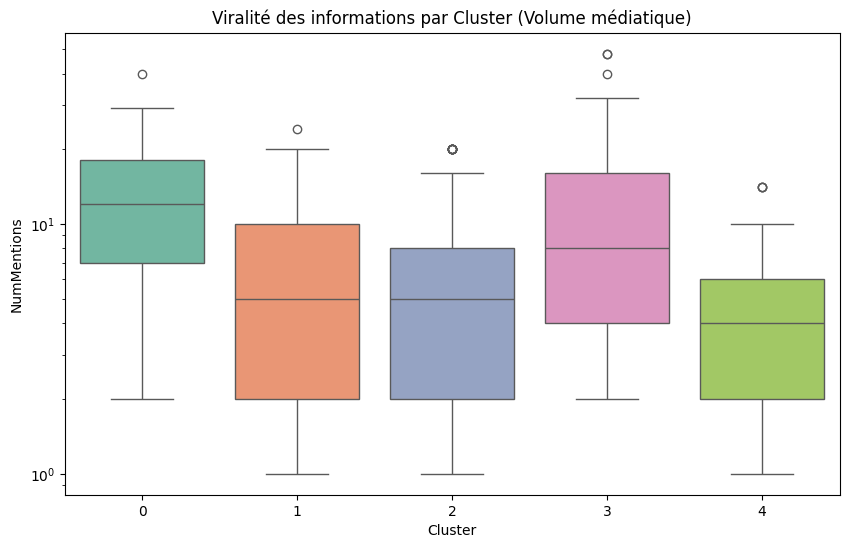

In [18]:
# Clustering GMM
import seaborn as sns
df_full = events.merge(mentions_summary, left_on='GlobalEventID', right_on="GlobalEventID")
gmm = GaussianMixture(n_components=5, random_state=42)
df_full['Cluster'] = gmm.fit_predict(X_scaled)

# Visualisation 1: Sentiment vs Impact (Image du pays)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_full, x='GoldsteinScale', y='AvgTone', hue='Cluster', palette='viridis', alpha=0.6)
plt.title('Analyse de l\'Image du Bénin : Impact (Goldstein) vs Sentiment (AvgTone)')
plt.axhline(0, color='red', linestyle='--')
plt.axvline(0, color='red', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

# Visualisation 2: Viralité par Cluster
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_full, x='Cluster', y='NumMentions', palette='Set2')
plt.title('Viralité des informations par Cluster (Volume médiatique)')
plt.yscale('log')
plt.show()


Le score BIC est utilisé pour l'optimisation des modèles de mélange gaussien (GMM). 

La règle est de choisir la valeur de n_clusters qui minimise le BIC.

**Chute Drastique** : On observe une baisse massive du score entre k=1 et k=2, signalant que les données sont naturellement multi-modales.

**Point d'Inflexion (Elbow)** : Un coude très marqué apparaît à k=5.

**Stagnation** : Après k=5, le gain (la diminution du score) devient marginal.

***Conclusion*** : Pour l'analyse de l'image du Bénin, l'utilisation de 5 clusters offre le meilleur compromis entre la précision de la segmentation et la complexité du modèle. Cela permettrait d'isoler des niches plus fines (ex: presse économique, incidents frontaliers, culture, diplomatie, et médias sociaux) plutôt que de rester sur une vision trop globale à 3 clusters.

#### Spectral Clustering Algorithms

/home/donerick/Hackaton-Isheero-Equipe-15/env/lib/python3.13/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


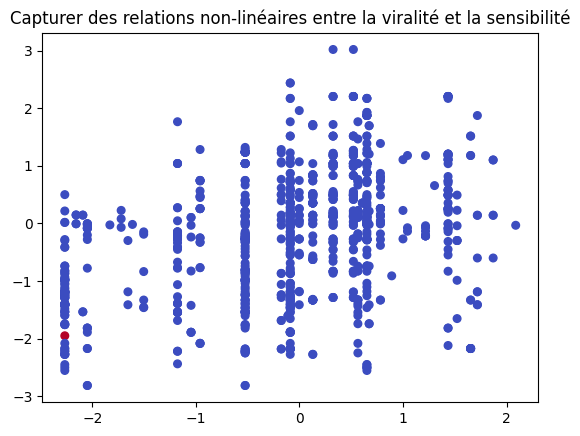

In [19]:
SC = SpectralClustering(
    n_components=5,
    affinity='rbf',
    n_neighbors=10,
    random_state=42,
    gamma=10.0
)
X = X_scaled[:1000]
labels_spectral = SC.fit_predict(X)


plt.scatter(X[:,0], X[:,1], c=labels_spectral, cmap='coolwarm', s=30)
plt.title('Capturer des relations non-linéaires entre la viralité et la sensibilité')
plt.show()

### Evaluation du MNS GMM

In [21]:
import joblib
# Évaluation rapide
df_full = events.merge(mentions_summary, left_on='GlobalEventID', right_on="GlobalEventID")

features_scale = ['GoldsteinScale', 'AvgTone', 'NumMentions', 'NumArticles', 'NumSources']
X_feature = events[features_scale].dropna()

X_scaled = scaler.fit_transform(X_feature)

model_gmm = GaussianMixture(
    n_components=5,
    random_state=42)

gmm_labels = model_gmm.fit_predict(X_feature)
gmm_score = silhouette_score(X_scaled, gmm_labels)


cluster_analysis = X_feature.copy()
cluster_analysis['Cluster_GMM'] = gmm_labels
summary = cluster_analysis.groupby('Cluster_GMM').mean()

# Sauvegarde du modèle GMM (souvent le plus adapté à la distribution du sentiment)
joblib.dump(model_gmm, 'best_gmm_model.pkl')
joblib.dump(scaler, 'scaler_image.pkl')

print("Scores et Profils des Clusters (GMM):")
print(summary)
print(f"\nSilhouette Score GMM: {gmm_score}")

Scores et Profils des Clusters (GMM):
             GoldsteinScale   AvgTone  NumMentions  NumArticles  NumSources
Cluster_GMM                                                                
0                 -0.505699 -2.331948    10.720207    10.523316    2.160622
1                 -6.867436 -4.576631     5.059346     5.059346    1.000000
2                  2.353016  4.142590     4.289177     4.289177    1.000000
3                  2.402057 -2.528695     4.906088     4.906088    1.000000
4                  0.061189 -1.638857    12.388112     7.167832    1.000000

Silhouette Score GMM: 0.13116736262321124


### Interprètation du résultats

Bien que le **Silhouette Score de 0.13** puisse paraître bas (sur une échelle de -1 à 1), il est tout à fait cohérent avec la nature des données GDELT et de l'image médiatique.

Dans le cadre de l'analyse de l'image du Bénin qui est d'ailleurs notre objectif, ce score raconte une histoire spécifique sur la structure de l'information mondiale.

Le modèle **Gaussian Mixture** capture ce chevauchement là où d'autres modèles forceraient une séparation artificielle.

**Densité vs Séparation**: Un score de 0.13 indique que les clusters sont denses mais proches les uns des autres. Cela reflète la réalité : la majorité des nouvelles internationales sur le Bénin gravitent autour d'un tronc commun de neutralité, avec des ramifications vers les crises ou les succès.